<a href="https://colab.research.google.com/github/amritha-279/DS_Aircraft_Efficiency/blob/main/q23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving aviation_aircraft_efficiency_dataset.csv to aviation_aircraft_efficiency_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("aviation_aircraft_efficiency_dataset.csv")

In [ ]:
df.head()

,Flight_ID,Aircraft_Type,Route,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers
0,FL1020,ATR72,Chennai-Pune,139.0,31.0,1190.0,72,51
1,FL1043,B737-800,Chennai-Delhi,217.0,50.0,1760.0,174,146
2,FL1155,B737-800,Chennai-Delhi,224.0,48.0,1760.0,174,142
3,FL1099,A320,Chennai-Madurai,53.0,68.0,460.0,180,162
4,FL1147,A321,Chennai-Hyderabad,61.0,74.0,510.0,220,176


In [ ]:
df.shape

(182, 8)

In [ ]:
df.columns

Index(['Flight_ID', 'Aircraft_Type', 'Route', 'Flight_Duration',
       'Turnaround_Time', 'Route_Distance', 'Passenger_Capacity',
       'Actual_Passengers'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Flight_ID           182 non-null    object 
 1   Aircraft_Type       182 non-null    object 
 2   Route               182 non-null    object 
 3   Flight_Duration     181 non-null    float64
 4   Turnaround_Time     181 non-null    float64
 5   Route_Distance      181 non-null    float64
 6   Passenger_Capacity  182 non-null    int64  
 7   Actual_Passengers   182 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 11.5+ KB


In [ ]:
df.isnull().sum()

,0
Flight_ID,0
Aircraft_Type,0
Route,0
Flight_Duration,1
Turnaround_Time,1
Route_Distance,1
Passenger_Capacity,0
Actual_Passengers,0


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Flight_ID,0
Aircraft_Type,0
Route,0
Flight_Duration,1
Turnaround_Time,1
Route_Distance,1
Passenger_Capacity,0
Actual_Passengers,0


In [ ]:
numeric_columns = [
    "Flight_Duration",
    "Turnaround_Time",
    "Route_Distance"
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [ ]:
df.isnull().sum()

,0
Flight_ID,0
Aircraft_Type,0
Route,0
Flight_Duration,0
Turnaround_Time,0
Route_Distance,0
Passenger_Capacity,0
Actual_Passengers,0


In [ ]:
df.describe()

,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers
count,180.000000,180.000000,180.000000,180.000000,180.000000
mean,113.094444,51.950000,928.444444,171.411111,134.288889
std,57.669129,11.784506,479.450130,43.666945,37.824128
min,40.000000,25.000000,290.000000,72.000000,45.000000
25%,59.000000,44.000000,510.000000,174.000000,121.000000
50%,125.000000,53.000000,1030.000000,180.000000,140.500000
75%,156.250000,60.000000,1380.000000,180.000000,159.000000
max,231.000000,75.000000,1760.000000,220.000000,209.000000


In [ ]:
df["Load_Factor"] = (
    df["Actual_Passengers"] / df["Passenger_Capacity"]
) * 100

In [ ]:
df[[
    "Aircraft_Type",
    "Passenger_Capacity",
    "Actual_Passengers",
    "Load_Factor"
]].head()

,Aircraft_Type,Passenger_Capacity,Actual_Passengers,Load_Factor
0,ATR72,72,51,70.833333
1,B737-800,174,146,83.908046
2,B737-800,174,142,81.609195
3,A320,180,162,90.000000
4,A321,220,176,80.000000


In [ ]:
invalid_passengers = df[
    df["Actual_Passengers"] > df["Passenger_Capacity"]
]

invalid_passengers

,Flight_ID,Aircraft_Type,Route,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers,Load_Factor


In [ ]:
df.to_csv("cleaned_aviation_dataset.csv", index=False)

In [ ]:
from google.colab import files

files.download("cleaned_aviation_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df["Aircraft_Type"].value_counts()

,count
Aircraft_Type,
B737-800,61
A320,56
A321,38
ATR72,25


In [ ]:
df["Route"].value_counts()

,count
Route,
Chennai-Pune,27
Chennai-Hyderabad,26
Chennai-Kolkata,26
Chennai-Mumbai,24
Chennai-Madurai,22
Chennai-Delhi,21
Chennai-Bengaluru,19
Chennai-Kochi,15


In [ ]:
aircraft_load = df.groupby("Aircraft_Type")["Load_Factor"].mean().sort_values(ascending=False)

aircraft_load

,Load_Factor
Aircraft_Type,
A321,79.114833
ATR72,78.666667
A320,78.005952
B737-800,78.000754


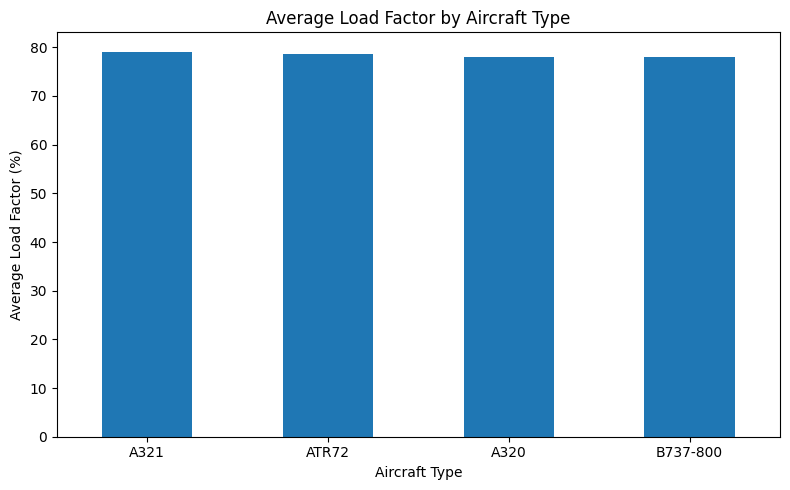

In [ ]:
plt.figure(figsize=(8, 5))

aircraft_load.plot(kind="bar")

plt.title("Average Load Factor by Aircraft Type")
plt.xlabel("Aircraft Type")
plt.ylabel("Average Load Factor (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
route_load = df.groupby("Route")["Load_Factor"].mean().sort_values()

route_load

,Load_Factor
Route,
Chennai-Kochi,63.627482
Chennai-Pune,70.423810
Chennai-Kolkata,75.506424
Chennai-Delhi,77.496434
Chennai-Hyderabad,79.616021
Chennai-Mumbai,82.740480
Chennai-Bengaluru,86.271472
Chennai-Madurai,89.000744


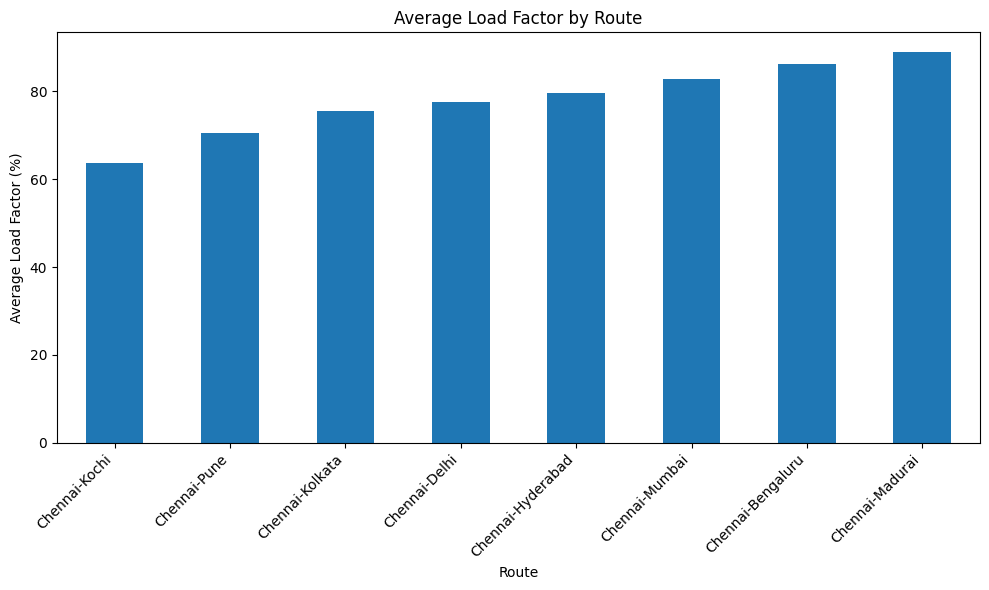

In [ ]:
plt.figure(figsize=(10, 6))

route_load.plot(kind="bar")

plt.title("Average Load Factor by Route")
plt.xlabel("Route")
plt.ylabel("Average Load Factor (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

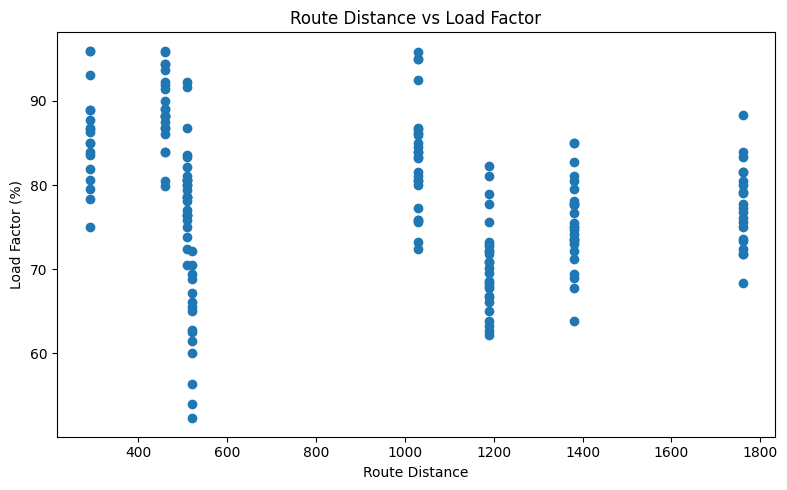

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Route_Distance"],
    df["Load_Factor"]
)

plt.title("Route Distance vs Load Factor")
plt.xlabel("Route Distance")
plt.ylabel("Load Factor (%)")
plt.tight_layout()
plt.show()

In [ ]:
correlation = df["Route_Distance"].corr(df["Load_Factor"])

print("Correlation between Route Distance and Load Factor:", correlation)

Correlation between Route Distance and Load Factor: -0.27370251400572293


The correlation between route distance and passenger load factor is −0.2737, indicating a weak negative relationship. Therefore, longer routes do not necessarily result in better aircraft utilization in this dataset.


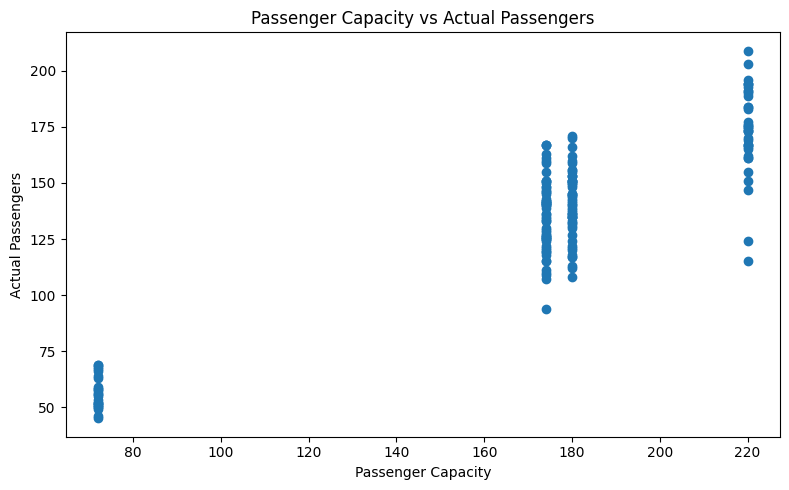

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Passenger_Capacity"],
    df["Actual_Passengers"]
)

plt.title("Passenger Capacity vs Actual Passengers")
plt.xlabel("Passenger Capacity")
plt.ylabel("Actual Passengers")
plt.tight_layout()
plt.show()

In [ ]:
aircraft_summary = df.groupby("Aircraft_Type").agg(
    Average_Load_Factor=("Load_Factor", "mean"),
    Average_Passengers=("Actual_Passengers", "mean"),
    Average_Capacity=("Passenger_Capacity", "mean"),
    Average_Flight_Duration=("Flight_Duration", "mean"),
    Average_Turnaround_Time=("Turnaround_Time", "mean"),
    Average_Distance=("Route_Distance", "mean")
)

aircraft_summary

,Average_Load_Factor,Average_Passengers,Average_Capacity,Average_Flight_Duration,Average_Turnaround_Time,Average_Distance
Aircraft_Type,,,,,,
A320,78.005952,140.410714,180.0,114.303571,56.178571,952.321429
A321,79.114833,174.052632,220.0,98.526316,62.236842,786.052632
ATR72,78.666667,56.640000,72.0,103.920000,33.120000,892.800000
B737-800,78.000754,135.721311,174.0,124.819672,49.377049,1009.836066


In [ ]:
X = df[
    [
        "Flight_Duration",
        "Turnaround_Time",
        "Route_Distance",
        "Passenger_Capacity"
    ]
]

y = df["Load_Factor"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    "Actual_Load_Factor": y_test.values,
    "Predicted_Load_Factor": y_pred
})

comparison.head(10)

,Actual_Load_Factor,Predicted_Load_Factor
0,88.333333,73.958944
1,87.727273,81.559223
2,68.965517,76.103837
3,83.908046,81.273225
4,72.777778,77.171920
5,75.909091,80.577711
6,63.888889,78.296975
7,85.057471,78.028882
8,80.459770,81.380387
9,75.000000,76.314107


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 7.377152570570601


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: -0.010161492742247091


In [ ]:
route_aircraft = df.groupby(
    ["Route", "Aircraft_Type"]
).agg(
    Average_Load_Factor=("Load_Factor", "mean"),
    Number_of_Flights=("Flight_ID", "count"),
    Average_Passengers=("Actual_Passengers", "mean")
).reset_index()

route_aircraft = route_aircraft.sort_values("Average_Load_Factor")

route_aircraft

,Route,Aircraft_Type,Average_Load_Factor,Number_of_Flights,Average_Passengers
13,Chennai-Kochi,A321,54.318182,2,119.500000
15,Chennai-Kochi,B737-800,60.536398,3,105.333333
14,Chennai-Kochi,ATR72,65.972222,2,47.500000
12,Chennai-Kochi,A320,66.527778,8,119.750000
30,Chennai-Pune,B737-800,69.540230,9,121.000000
28,Chennai-Pune,A321,69.545455,3,153.000000
29,Chennai-Pune,ATR72,69.675926,6,50.166667
27,Chennai-Pune,A320,72.098765,9,129.777778
18,Chennai-Kolkata,ATR72,73.263889,4,52.750000
19,Chennai-Kolkata,B737-800,73.719958,11,128.272727


In [ ]:
reliable_combinations = route_aircraft[
    route_aircraft["Number_of_Flights"] >= 5
].sort_values("Average_Load_Factor")

reliable_combinations

,Route,Aircraft_Type,Average_Load_Factor,Number_of_Flights,Average_Passengers
12,Chennai-Kochi,A320,66.527778,8,119.750000
30,Chennai-Pune,B737-800,69.540230,9,121.000000
29,Chennai-Pune,ATR72,69.675926,6,50.166667
27,Chennai-Pune,A320,72.098765,9,129.777778
19,Chennai-Kolkata,B737-800,73.719958,11,128.272727
7,Chennai-Delhi,B737-800,76.181354,9,132.555556
11,Chennai-Hyderabad,B737-800,77.668309,7,135.142857
4,Chennai-Delhi,A320,78.809524,7,141.857143
16,Chennai-Kolkata,A320,78.819444,8,141.875000
9,Chennai-Hyderabad,A321,79.191919,9,174.222222


In [ ]:
inefficient_combinations = reliable_combinations[
    reliable_combinations["Average_Load_Factor"] < 70
]

inefficient_combinations

,Route,Aircraft_Type,Average_Load_Factor,Number_of_Flights,Average_Passengers
12,Chennai-Kochi,A320,66.527778,8,119.750000
30,Chennai-Pune,B737-800,69.540230,9,121.000000
29,Chennai-Pune,ATR72,69.675926,6,50.166667


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 7.377152570570601
Root Mean Squared Error: 9.178349805457154
R2 Score: -0.010161492742247091


Practical Action Plan

1. **Review low-occupancy routes**
   Investigate routes such as **Chennai-Kochi**, which showed a relatively low average load factor, and review passenger demand before assigning aircraft capacity.

2. **Match aircraft capacity with passenger demand**
   Use smaller-capacity aircraft on routes with consistently lower passenger demand and assign higher-capacity aircraft to routes with stronger passenger occupancy.

3. **Review inefficient route-aircraft combinations**
   Identify route-aircraft combinations with low average load factors and consider changing the aircraft type assigned to those routes.

4. **Prioritize high-demand routes**
   Routes with consistently high load factors, such as **Chennai-Madurai and Chennai-Bengaluru**, should be monitored for increasing demand and capacity requirements.

5. **Use demand rather than distance alone for fleet planning**
   The correlation between route distance and load factor was **−0.2737**, indicating a weak negative relationship. Therefore, aircraft allocation should consider passenger demand and historical load factor rather than route distance alone.

6. **Monitor aircraft utilization regularly**
   Track load factor, passenger numbers, route distance, and turnaround time regularly to identify changes in aircraft efficiency and adjust fleet allocation accordingly.

